# LOS Bolometry Surrogate Data Frame (Standalone)

Generate (emissivity, measurements) pairs using the forward model only.
Geometry is fixed; this is **not** a GA workflow.


In [1]:
import numpy as np

from indica.defaults.load_defaults import load_default_objects
from indica.models import PinholeCamera
from indica.operators.atomic_data import default_atomic_data
from los_bolometry_geometry import origin_from_polar_angle, direction_from_polar_and_dir_offset,update_los
import matplotlib.pyplot as plt

In [2]:
# Basic setup (lifted from the beginning of run_example_diagnostic_model)
machine = "st40"
instrument = "blom_xy1"

# Initialise plasma and diagnostic model
transforms = load_default_objects(machine, "geometry")
equilibrium = load_default_objects(machine, "equilibrium")
plasma = load_default_objects(machine, "plasma")

plasma.set_equilibrium(equilibrium)
transform = transforms[instrument]
transform.set_equilibrium(equilibrium)
transform.spot_shape = "square"
transform.focal_length = -1000.0

# Model setup
_, power_loss = default_atomic_data(["h", "ar", "c", "he"])
model = PinholeCamera(instrument, power_loss=power_loss)
model.set_transform(transform)
model.set_plasma(plasma)

# TODO: change plasma here if you want to sample a different emissivity field
# Example: plasma.<...> = <...>


## Chosen frozen sensor geometry

/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2001: UserWarning: The following kwargs were not used by contour: 'linestyle'
  primitive = ax.contour(x, y, z, **kwargs)


Previewed LOS geometry for pulse 13622 (blom_xy1)


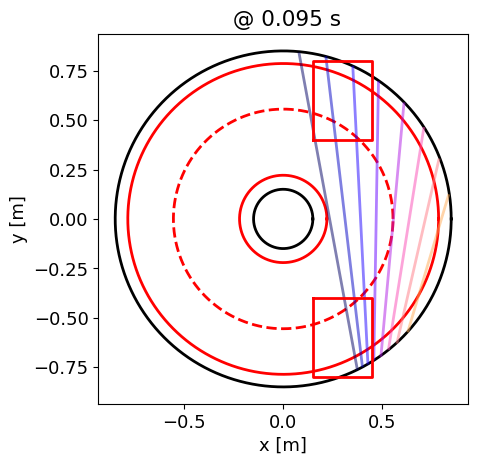

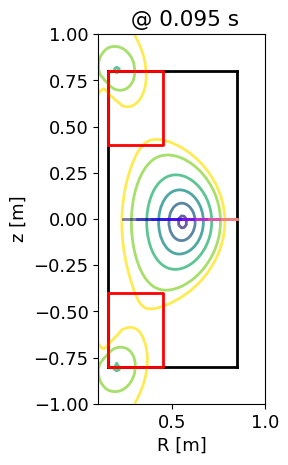

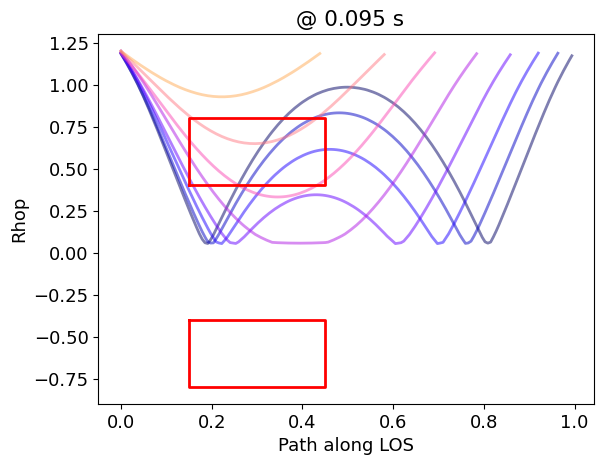

In [3]:

from indica import Equilibrium
from indica.readers import ST40Reader

# Preview LOS geometry from a real pulse.
# This cell is for visualization only and does not set/overwrite `individual`.
preview_pulse = 13622
preview_tstart = 0.04
preview_tend = 0.15
preview_dt = 0.01

preview_reader = ST40Reader(
    preview_pulse,
    preview_tstart - preview_dt,
    preview_tend + preview_dt,
    dt=preview_dt,
    verbose=False,
)
preview_equilibrium_data = preview_reader.get("", "efit", 0)
preview_equilibrium = Equilibrium(preview_equilibrium_data)

preview_instrument_data = preview_reader.get("", instrument, 0)
preview_quantity = next(iter(preview_instrument_data))
preview_transform = preview_instrument_data[preview_quantity].attrs["transform"]
preview_transform.set_equilibrium(preview_equilibrium, force=True)

update_los(preview_transform)
preview_transform.plot()
print(f"Previewed LOS geometry for pulse {preview_pulse} ({instrument})")


## Plasma generator

In [4]:
from indica.workflows.plasma_profiler_init import load_bda_config, build_plasma_profiler, sample_prior_parameters

class PlasmaGenerator():
    def __init__(self, model,transform,config_name="ion_temperature_phantom_run_all_params"):
        self.model = model
        self.transform = transform
        self.cfg = load_bda_config(
            config_name="ion_temperature_phantom_run_all_params",
            overrides=[
                "plasma.settings.n_rad=41",
                "tstart=0.04",
                "tend=0.15",
                "dt=0.01",
            ],
            )
        self.plasma_profiler = build_plasma_profiler(self.cfg)

    def generate(self):
        all_params = sample_prior_parameters(self.cfg)
        self.plasma_profiler(all_params)
        return self.plasma_profiler.plasma
    
    def run_model(self,target_plasma=None):
        if target_plasma is not None:
            self.model.set_plasma(target_plasma)
        else:
            self.model.set_plasma(self.plasma_profiler.plasma)
            
        self.model.set_transform(self.transform)
        bckc, emissivity = self.model(return_emissivity=True)
        measurements = bckc["brightness"]
        return(measurements, emissivity)

    
    



## Data generation and writing

In [5]:
#Generate all the pairs of (emissivity, measurements) for the given plasma. 
#No temporal relations, each time step is independent for now.
b_slices=[]
eps_slices=[]
generate_new_data=False
b_dir="jussitesting/vae_firstpass/b_slices.csv"
eps_dir="jussitesting/vae_firstpass/eps_slices.csv"
if generate_new_data:
    
    import csv
    generator=PlasmaGenerator(model,transform)
    use_all_timepoints = False  # Set True when generator has meaningful time dynamics.
    for r in range(4000):
        if not r%200:
            print(f"Elapsed: {r}/2000")
        generator.generate()
        measurements, emissivity = generator.run_model()
        if use_all_timepoints:
            t_indices = range(measurements.sizes["t"])
        else:
            #If random index
            t_indices = [np.random.randint(measurements.sizes["t"])]
            #Central index
            #t_indices=[int(measurements.sizes["t"]/2)]
        for t_idx in t_indices:
            channel_vector = measurements.isel(t=t_idx).values.astype(np.float32)
            emissivity_slice = emissivity.isel(t=t_idx).values.astype(np.float32)
            b_slices.append(channel_vector)
            eps_slices.append(emissivity_slice)
    print(len(b_slices), len(eps_slices))
    b_slices=np.array(b_slices)
    eps_slices=np.array(eps_slices)
    print(b_slices.shape, eps_slices.shape)



    with open(b_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(b_slices)
    with open(eps_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(eps_slices)

        

## FIlter pulses

In [8]:
from indica.readers.st40_pulse_filtering import filter_pulses
import pickle
r_start=13500
r_end=14000
valids, invalids=filter_pulses(range(r_start,r_end))
print(len(valids))
with open(f'valids_range_{r_start}_{r_end}.pkl', 'wb') as f:
    pickle.dump(valids,f)


Checking pulse 13500 for plasma
Checking pulse 13501 for plasma
Checking pulse 13502 for plasma
Checking pulse 13503 for plasma
Checking pulse 13504 for plasma
Checking pulse 13505 for plasma
Checking pulse 13506 for plasma
Checking pulse 13507 for plasma
Checking pulse 13508 for plasma
Checking pulse 13509 for plasma
Checking pulse 13510 for plasma
Checking pulse 13511 for plasma
Checking pulse 13512 for plasma
Checking pulse 13513 for plasma
Checking pulse 13514 for plasma
Checking pulse 13515 for plasma
Checking pulse 13516 for plasma
Checking pulse 13517 for plasma
Checking pulse 13518 for plasma
Checking pulse 13519 for plasma
Checking pulse 13520 for plasma
Checking pulse 13521 for plasma
Checking pulse 13522 for plasma
Checking pulse 13523 for plasma
Checking pulse 13524 for plasma
Checking pulse 13525 for plasma
Checking pulse 13526 for plasma
Checking pulse 13527 for plasma
Checking pulse 13528 for plasma
Checking pulse 13529 for plasma
Checking pulse 13530 for plasma
Checking

In [ ]:
# Multi-pulse real-data dataset generation (ST40Reader-based)
# Builds (measurements, emissivity) pairs like the cell above, but scans a pulse range.
import csv

from indica import Equilibrium
from indica.examples.example_plasma import example_plasma
from indica.models import PinholeCamera
from indica.operators.atomic_data import default_atomic_data
from indica.readers import ST40Reader

machine = 'st40'
instrument = 'blom_xy1'
tstart = 0.04
tend = 0.15
dt = 0.01
filtered_pulses=valids
use_all_timepoints = True

b_dir = 'jussitesting/vae_firstpass/b_slices_multipulse.csv'
eps_dir = 'jussitesting/vae_firstpass/eps_slices_multipulse.csv'
meta_dir = 'jussitesting/vae_firstpass/sample_meta_multipulse.csv'

b_slices = []
eps_slices = []
sample_meta = []

_, power_loss = default_atomic_data(['h', 'ar', 'c', 'he'])

def build_real_model_for_pulse(pulse: int):
    reader = ST40Reader(pulse, tstart - dt, tend + dt, dt=dt, verbose=False)

    equilibrium_data = reader.get('', 'efit', 0)
    equilibrium = Equilibrium(equilibrium_data)

    plasma = example_plasma(
        machine=machine,
        tstart=tstart,
        tend=tend,
        dt=dt,
        main_ion='h',
        impurities=('c', 'ar', 'he'),
        full_run=False,
        n_rad=41,
        n_R=100,
        n_z=100,
    )
    plasma.set_equilibrium(equilibrium)

    # Seed plasma profiles from measured fitted profiles on rhop
    ppts = reader.get('', 'ppts', 0)
    plasma.electron_density.loc[dict(t=plasma.t)] = (
        ppts['ne_rhop'].interp(t=plasma.t, rhop=plasma.rhop).transpose('t', 'rhop').values
    )
    plasma.electron_temperature.loc[dict(t=plasma.t)] = (
        ppts['te_rhop'].interp(t=plasma.t, rhop=plasma.rhop).transpose('t', 'rhop').values
    )

    instrument_data = reader.get('', instrument, 0)
    first_quantity = next(iter(instrument_data))
    transform = instrument_data[first_quantity].attrs['transform']
    transform.set_equilibrium(equilibrium, force=True)
    transform.spot_shape = 'square'
    transform.focal_length = -1000.0
    """
    # Reapply frozen LOS layout if the 'individual' vector is available in the notebook
    if 'individual' in globals():
        indiv = individual
        N = len(indiv) // 2
        los_angles = indiv[:N]
        offsets = indiv[N:]
        directions = []
        origins = []
        for i in range(N):
            new_origin_x, new_origin_z = origin_from_polar_angle(los_angles[i], transform)
            origins.append((new_origin_x, 0, new_origin_z))
            new_dir_x, new_dir_z = direction_from_polar_and_dir_offset(
                los_angles[i], offsets[i], transform
            )
            directions.append((new_dir_x, 0, new_dir_z))
        transform.set_origin(np.array(origins))
        transform.set_direction(np.array(directions))
        update_los(transform)
    """

    model = PinholeCamera(instrument, power_loss=power_loss)
    model.set_transform(transform)
    model.set_plasma(plasma)
    return model

for pulse in filtered_pulses:
    try:
        model_pulse = build_real_model_for_pulse(pulse)
        bckc, emissivity = model_pulse(return_emissivity=True)
        measurements = bckc['brightness']

        if use_all_timepoints:
            t_indices = range(measurements.sizes['t'])
        else:
            t_indices = [np.random.randint(measurements.sizes['t'])]

        for t_idx in t_indices:
            channel_vector = measurements.isel(t=t_idx).values.astype(np.float32)
            emissivity_slice = emissivity.isel(t=t_idx).values.astype(np.float32)
            b_slices.append(channel_vector)
            eps_slices.append(emissivity_slice)
            sample_meta.append((pulse, float(measurements.t.isel(t=t_idx).values)))

        print(f'Pulse {pulse}: added {len(list(t_indices))} samples')
    except Exception as exc:
        print(f'Skipping pulse {pulse}: {exc}')

b_slices = np.array(b_slices, dtype=np.float32)
eps_slices = np.array(eps_slices, dtype=np.float32)
print('Final shapes:', b_slices.shape, eps_slices.shape)

with open(b_dir, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(b_slices)
with open(eps_dir, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(eps_slices)
with open(meta_dir, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['pulse', 'time_s'])
    writer.writerows(sample_meta)

print(f'Wrote: {b_dir}, {eps_dir}, {meta_dir}')


no profile params given so updating all
Skipping pulse 13500: 'R_data'
no profile params given so updating all
Pulse 13501: added 9 samples
no profile params given so updating all
Pulse 13509: added 9 samples
no profile params given so updating all
Pulse 13510: added 9 samples
no profile params given so updating all
Pulse 13511: added 9 samples
no profile params given so updating all
Available equilibrium time [0.01044349 0.01098712 0.01153076 0.01207439 0.01261803 0.01316166 0.01370529 0.01424893 0.01479256
 0.0153362  0.01587983 0.01642346 0.0169671  0.01751073 0.01805436 0.018598   0.01914163 0.01968526
 0.0202289  0.02077253 0.02131617 0.0218598  0.02240343 0.02294707 0.0234907  0.02403433 0.02566524
 0.02620887]
Skipping pulse 13512: Inserted time [0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1 ] is not available in Equilibrium object
no profile params given so updating all
Pulse 13513: added 9 samples
Skipping pulse 13519: 'rbnd'
Skipping pulse 13520: 'rbnd'
Skipping pulse 13521: 'r

In [ ]:
# Remove zero-heavier (measurement, emissivity) pairs from the same CSV files.
import csv
import numpy as np
b_slices = np.loadtxt(b_dir, delimiter=',', dtype=np.float32)
eps_slices = np.loadtxt(eps_dir, delimiter=',', dtype=np.float32)

if b_slices.ndim == 1:
    b_slices = b_slices[None, :]
if eps_slices.ndim == 1:
    eps_slices = eps_slices[None, :]

if len(b_slices) != len(eps_slices):
    raise ValueError('b_dir and eps_dir must contain the same number of samples')

zero_counts = (
    np.count_nonzero(b_slices == 0.0, axis=1)
    + np.count_nonzero(eps_slices == 0.0, axis=1)
)
min_zero_count = int(zero_counts.min())+50
keep_mask = zero_counts <= min_zero_count

b_filtered = b_slices[keep_mask]
eps_filtered = eps_slices[keep_mask]

with open(b_dir, 'w', newline='') as f:
    csv.writer(f).writerows(b_filtered)
with open(eps_dir, 'w', newline='') as f:
    csv.writer(f).writerows(eps_filtered)

if 'meta_dir' in globals():
    try:
        with open(meta_dir, newline='') as f:
            rows = list(csv.reader(f))
        has_header = bool(rows) and rows[0] == ['pulse', 'time_s']
        header = rows[0] if has_header else None
        data_rows = rows[1:] if has_header else rows
        if len(data_rows) == len(keep_mask):
            filtered_meta = [row for row, keep in zip(data_rows, keep_mask) if keep]
            with open(meta_dir, 'w', newline='') as f:
                writer = csv.writer(f)
                if header is not None:
                    writer.writerow(header)
                writer.writerows(filtered_meta)
            print(f'Updated meta file: {meta_dir}')
        else:
            print('meta_dir row count did not match sample count; left meta file unchanged')
    except FileNotFoundError:
        print(f'meta file not found: {meta_dir}')

print(
    f'Kept {int(keep_mask.sum())} / {len(keep_mask)} pairs (removed {int((~keep_mask).sum())}); '
    f'min zero-count was {min_zero_count}'
)


Updated meta file: jussitesting/vae_firstpass/sample_meta_multipulse.csv
Kept 927 / 927 pairs (removed 0); min zero-count was 50


## Dataset creation


In [ ]:

import csv
import os

from torch.utils.data import Dataset, DataLoader
import torch

class PairDataset(Dataset):
    def __init__(self, b_dir, eps_dir, meta_dir=None, zero_tol=0.0):
        self.b_dir = b_dir
        self.eps_dir = eps_dir
        self.meta_dir = meta_dir
        self.zero_tol = float(zero_tol)
        self.b_slices = np.loadtxt(b_dir, delimiter=',', dtype=np.float32)
        self.eps_slices = np.loadtxt(eps_dir, delimiter=',', dtype=np.float32)
        if self.b_slices.ndim == 1:
            self.b_slices = self.b_slices[None, :]
        if self.eps_slices.ndim == 1:
            self.eps_slices = self.eps_slices[None, :]
        if len(self.b_slices) != len(self.eps_slices):
            raise ValueError('b_dir and eps_dir must contain the same number of samples')

        self.mu_b, self.sigma_b = np.mean(self.b_slices), np.std(self.b_slices)
        self.mu_eps, self.sigma_eps = np.mean(self.eps_slices), np.std(self.eps_slices)

        b_zeros = np.count_nonzero(np.abs(self.b_slices) <= self.zero_tol, axis=1)
        eps_zeros = np.count_nonzero(np.abs(self.eps_slices) <= self.zero_tol, axis=1)
        total_dims = self.b_slices.shape[1] + self.eps_slices.shape[1]
        self.sample_nonzero_fraction = 1.0 - (b_zeros + eps_zeros) / total_dims

        self.pulse_quality = {}
        self.best_pulse = None
        if meta_dir is not None and os.path.exists(meta_dir):
            with open(meta_dir, newline='') as f:
                rows = list(csv.reader(f))
            has_header = bool(rows) and rows[0] == ['pulse', 'time_s']
            data_rows = rows[1:] if has_header else rows
            if len(data_rows) == len(self.sample_nonzero_fraction):
                pulse_to_scores = {}
                for row, score in zip(data_rows, self.sample_nonzero_fraction):
                    pulse = int(float(row[0]))
                    pulse_to_scores.setdefault(pulse, []).append(float(score))
                self.pulse_quality = {
                    pulse: float(np.mean(scores)) for pulse, scores in pulse_to_scores.items()
                }
                if self.pulse_quality:
                    self.best_pulse = max(self.pulse_quality, key=self.pulse_quality.get)

    def get_top_pulses(self, n=5, min_nonzero_fraction=0.0):
        if not self.pulse_quality:
            return []
        return [
            (pulse, score)
            for pulse, score in sorted(
                self.pulse_quality.items(), key=lambda x: x[1], reverse=True
            )
            if score >= min_nonzero_fraction
        ][:n]


    def __len__(self):
        return len(self.b_slices)
    
    def __getitem__(self, idx):
        b_slice = self.b_slices[idx]
        eps_slice = self.eps_slices[idx]
        return(eps_slice-self.mu_eps)/self.sigma_eps,(b_slice-self.mu_b)/self.sigma_b

In [ ]:
dataset = PairDataset(b_dir, eps_dir, meta_dir=meta_dir if 'meta_dir' in globals() else None)
if dataset.best_pulse is not None:
    best_score = dataset.pulse_quality[dataset.best_pulse]
    print(f'Best pulse by mean nonzero fraction: {dataset.best_pulse} ({best_score:.3f})')
    print('Top 20 pulses:', dataset.get_top_pulses(n=20))
else:
    print('Pulse-level quality unavailable (missing/unmatched meta_dir).')

trainsplit, testsplit=torch.utils.data.random_split(dataset, lengths=[int(0.8*len(dataset)), len(dataset) - int(0.8*len(dataset))])

train_dataloader=DataLoader(trainsplit, batch_size=8, shuffle=True)
test_dataloader=DataLoader(testsplit, batch_size=8, shuffle=True)

print(len(train_dataloader))

Best pulse by mean nonzero fraction: 13564 (0.683)
Top 20 pulses: [(13564, 0.6825396825396826), (13563, 0.6757369614512472), (13597, 0.6666666666666666), (13587, 0.6643990929705216), (13565, 0.6598639455782312), (13567, 0.6598639455782312), (13570, 0.6598639455782312), (13586, 0.5736961451247166), (13560, 0.5691609977324263), (13685, 0.5691609977324262), (13566, 0.564625850340136), (13681, 0.564625850340136), (13682, 0.564625850340136), (13572, 0.5578231292517006), (13511, 0.5532879818594104), (13689, 0.4761904761904763), (13690, 0.47392290249433106), (13538, 0.46031746031746024), (13510, 0.45804988662131524), (13662, 0.45804988662131524)]
93


## Sanity check

#### Notation
- $p_\theta$ denotes a generative model, parameterized by $\theta$
- $q_\phi$ denotes the variational approximation (encoder), parametrized by $\phi$ 
- In variational bayes, p is true model and q approximating dist. Also phi is inference parameter and theta generative parameter.


#### Currently we have:
- A collection of (8,) shaped bolometer signals $b$, each one is from a different time slice-> right now, consider time independent
- A matching collection of (41,) shaped emissivity signals $e$, same thing.
- We have a torch dataset defined for this, and this dataset has normalisation coefficients computed. Scale when we  call getitem.

#### Conceptual model definiton - dummy edition

Three random variables:
1) Emissivity $e \in \real^{41}$. What we observe during training, this is what the model targets.
2) Latent variable $z \in \real^{d}$. Unobserved.
3) Bolometry $b \in \real^{8}$. Observed and conditioned on. 

ie. Given $b$, sample $z$, then generate $e$.

#### Decoder 

1) Draw a latent variable from a standard normal: $Z \sim \mathcal{N}(0,I)$ 
2) Given a bolometer measurement $b$ and a latent variable $z$, the emissivity follows a distribution parametrized by the decoder network:  $e | (b,z) \sim p_{\theta}(e | b,z)$
3) When conditioned on $b$ and $z$, the emissivity follows a Gaussian whose mean is predicted by the decoder network, covariance is identity ie. decoder only predicts the mean emissivity, all remaining uncertainty is represented by $z$ ie.  $p_{\theta}(e | b,z) = \mathcal{N}(\mu_\theta (b,z),I)$.

#### Encoder
1) The approximate posterior over $z$, conditioned on both $e$ and $b$, $q_{\phi}(z|e,b)$, $= \mathcal{N}(\mu_z (e,b), diag (\sigma^2_z (e,b)))$. The encoder takes emissivity and bolometer inputs, and outputs mean and variacne of a Gaussian over $z$.
2) This is same as saying "which latent variables could have plausibly produced the observed emissivity, when combined with the bolometry?"

#### Training

1) We take an emissivity and bolometry inputs and then when given into the encoder, the encoder gives the Gaussian parameters for the latent variable as: $(\mu_z,\sigma_z) =Encoder(e,b)$
2) Sample the latent by adding gaussian noise to encoder mean scaled with the predicted sd: $z=\mu_z+\sigma_z \odot \epsilon, \epsilon \sim \mathcal{N}(0,I)$. 
3) Last step used reparametrization trick. Since Z is sampled, and sampling is not differentiable, gradients cannot flow through a random draw. Instead of sampling from the gaussian whose params I am trying to learn, I take standard noise and transform this using the params I wanna learn. This becomes differentiable and gradients can flow through!
4) Decode: decoder takes bolometer measurement and sampled latent, and outputs a predicted emissivity profile $\hat{e}=\mu_\theta (b,z)$


#### Loss
1) Reconstruction term, square difference between true emissivity and predicted: $||e-\hat{e}||^2$. We assume Gaussian with unit variance for decoder, so squared error is proportional to negative log-likelihood of true emissivity under the model. DO the math! 
2) KL-divegence term: Measures how different the encoders inferred latent dist is from a standard noraml. Basically, this means the encoder has to use the bolometer as well and not just try to hide everything behind the latent variables:
$KL(q_\phi (z|e,b) || \mathcal{N}(0,I))$

3) The combined loss: model is trained to reconstruct the observed emissivity and keep the latent variables close to a Gaussian. $\mathcal{L} = \mathbb{E}_{q_\theta (z|e,b)}[||e-\hat{e}||^2]+KL(q_\phi (z|e,b) || \mathcal{N}(0,I))$. ANother wording: First loss term is the squared recosnstruction error in the emissivity, when expectation is taken wrt the approximate posterior over the latent variables and standard normal prior.


Basically: 


#### Inference time
1) Encoder is not used
2) Sample from latent, and let decoder figure what the emissivity would be based on that.

## cVAE structure and training

In [ ]:
#Note that encoder takes in 41+6! I changed dataloader order.
from torch import nn
import torch

latent_dim=4


class Network(nn.Module):
    def __init__(self, input_dim=49, latent_dim=4):
        super(Network, self).__init__()
        self.fc1m = nn.Linear(input_dim, 64)
        self.fc1s = nn.Linear(input_dim, 64)

        self.fc2m = nn.Linear(64, 32)
        self.fc2s = nn.Linear(64, 32)
        
        self.fc3m = nn.Linear(32, latent_dim)
        self.fc3s = nn.Linear(32, latent_dim)



        self.fc_dec1 = nn.Linear(latent_dim + 8, 32)
        self.fc_dec2 = nn.Linear(32, 64)
        self.fc_dec3 = nn.Linear(64, 41)
    #encode
    def encode(self, emis, bolom ):
        x = torch.cat((emis, bolom), dim=1)

        m = torch.relu(self.fc1m(x))
        logvar = torch.relu(self.fc1s(x))

        m = torch.relu(self.fc2m(m))
        logvar = torch.relu(self.fc2s(logvar))
        
        m = self.fc3m(m)
        logvar = self.fc3s(logvar)
        return m, logvar
    
    def decode(self, b,z):
        x=torch.cat((b,z), dim=1)
        x = torch.relu(self.fc_dec1(x))
        x = torch.relu(self.fc_dec2(x))
        x = self.fc_dec3(x)
        return x

    def reparametrize(self,m, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return m + eps * std
    
    def KL_divergence(self, m, logvar):
        return -0.5 * torch.sum(1 + logvar - m.pow(2) - logvar.exp(), dim=1)
    
    def total_loss(self, recon_x, x, m, logvar, return_components=False, kl_beta=0):
        recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
        kl_loss = self.KL_divergence(m, logvar).sum()
        #print("Recon mean: ", recon_loss.item()/x.shape[0], "KL mean: ", kl_loss.item()/x.shape[0])
        total = (recon_loss + kl_beta * kl_loss) / x.shape[0]
        if return_components:
            return total, recon_loss / x.shape[0], kl_loss*kl_beta / x.shape[0]
        return total
    

    def forward(self, emis, bolom):
        m, logvar = self.encode(emis, bolom)
        z = self.reparametrize(m, logvar)
        e_hat = self.decode(bolom, z)
        return e_hat, m, logvar, z
    

def train(model, epoch, optimizer, n_epochs=30):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0
    kl_epoch_beta = (epoch / n_epochs)*0.5
    for batch_idx, (emis, bolom) in enumerate(train_dataloader):
        optimizer.zero_grad()
        recon_emis, m, logvar, z = model(emis, bolom)
        loss,rec,kl = model.total_loss(recon_emis, emis, m, logvar, return_components=True,kl_beta=kl_epoch_beta)
        loss.backward()
        train_loss += loss.item()
        recon_loss_total += rec.item()
        kl_loss_total += kl.item()
        optimizer.step()
    print(f'====> Epoch: {epoch} Average loss: {train_loss/len(train_dataloader):.4f}')
    print(f'====> Epoch: {epoch} Average recon loss: {recon_loss_total/len(train_dataloader):.4f} Average KL loss: {kl_loss_total/len(train_dataloader):.4f}')
    
vaemodel=Network(latent_dim=latent_dim)
total_params = sum(p.numel() for p in vaemodel.parameters())
print(f"Total number of parameters in the VAE model: {total_params}")
optimizer=torch.optim.Adam(vaemodel.parameters(), lr=1e-3)
n_epochs=25
for epoch in range(1, n_epochs): 
    train(vaemodel,epoch,optimizer,n_epochs=n_epochs)

Total number of parameters in the VAE model: 16017


====> Epoch: 1 Average loss: 16.2568
====> Epoch: 1 Average recon loss: 16.0924 Average KL loss: 0.1644
====> Epoch: 2 Average loss: 2.2254
====> Epoch: 2 Average recon loss: 1.9107 Average KL loss: 0.3147
====> Epoch: 3 Average loss: 1.9913
====> Epoch: 3 Average recon loss: 1.6863 Average KL loss: 0.3050
====> Epoch: 4 Average loss: 1.5557
====> Epoch: 4 Average recon loss: 1.2961 Average KL loss: 0.2596
====> Epoch: 5 Average loss: 1.0751
====> Epoch: 5 Average recon loss: 0.8174 Average KL loss: 0.2577
====> Epoch: 6 Average loss: 0.8559
====> Epoch: 6 Average recon loss: 0.6202 Average KL loss: 0.2357
====> Epoch: 7 Average loss: 0.7678
====> Epoch: 7 Average recon loss: 0.5449 Average KL loss: 0.2229
====> Epoch: 8 Average loss: 0.7579
====> Epoch: 8 Average recon loss: 0.5584 Average KL loss: 0.1995
====> Epoch: 9 Average loss: 0.7011
====> Epoch: 9 Average recon loss: 0.5041 Average KL loss: 0.1970
====> Epoch: 10 Average loss: 0.6132
====> Epoch: 10 Average recon loss: 0.4462 

## Sanity checks: diversity and fw consistency metrics: one set of values and intuition



### Conditional sampling diversity
- Mean L2 distance to sample-mean : 0.057555 -> Average spread of the posterior ie. how far are samples from the posterior mean? How concentrated is my posterior?
- Max per-dim std: 0.103400  -> In regions where the uncertainty is the strongest, how strong is it?
- L2(sample-mean, true e): 0.061272 -> Bias of the posterior mean. Is posterior centered correctly around the true value?


### Forward consistency

- Mean L2: 0.095481 -> Are the sampled emissivities consistent with the conditioning measurement? If large, posterior samples do not adhere to the bolometry measurement conditioning.
- Max abs error : 0.213974 -> Largest single bolometer channel inconsistency. Fw model measurements vs the actual measurements!

In [ ]:
import torch

vaemodel.eval()

K = 100
idx = 10  

# Single example from the dataset
test_dataset = test_dataloader.dataset
e_true, b_star = test_dataset[idx]          
e_true = torch.from_numpy(e_true).unsqueeze(0)                
b_star = torch.from_numpy(b_star).unsqueeze(0)                

#Latent dim
latent_dim = vaemodel.fc3m.out_features

with torch.no_grad():
    # Sample K latents
    z = torch.randn(K, latent_dim)           
    # Repeat b* K times
    b_rep = b_star.expand(K, -1)                            

    # Decode K samples
    e_samps = vaemodel.decode(b_rep, z)                     

#  Use the same dataset object for stats. It has mu and sigma for unnormalization.
subset=test_dataloader.dataset
dataset=subset.dataset

#Diversity metrics


with torch.no_grad():
    #unnormalize samples and true value
    e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
    e_true_un  = e_true  * dataset.sigma_eps + dataset.mu_eps

    e_mean_un = e_samps_un.mean(dim=0, keepdim=True)        
    l2_to_mean = torch.norm(e_samps_un - e_mean_un, dim=1)  
    mean_l2 = l2_to_mean.mean().item()

    std_per_dim = e_samps_un.std(dim=0)                     # (41,)
    mean_std = std_per_dim.mean().item()
    max_std  = std_per_dim.max().item()

    e_scale = torch.norm(e_true_un, dim=1).item() + 1e-8
    mean_l2_norm  = mean_l2 / e_scale
    mean_std_norm = mean_std / (e_scale / (e_true_un.shape[1] ** 0.5))
    max_std_norm  = max_std  / (e_scale / (e_true_un.shape[1] ** 0.5))

print("Conditional sampling diversity")
print(f"K = {K}, idx = {idx}")
print(f"Mean L2 distance to sample-mean (norm): {mean_l2_norm:.6f}")
print(f"Mean per-dim std (norm): {mean_std_norm:.6f}")
print(f"Max  per-dim std (norm): {max_std_norm:.6f}")

err_to_true = torch.norm(e_mean_un - e_true_un, dim=1).item()
print(f"L2(sample-mean, true e) (norm): {(err_to_true / e_scale):.6f}")

# FW consistency metrics
e_all = torch.as_tensor(dataset.eps_slices)  # (N,41) unnormalized
b_all = torch.as_tensor(dataset.b_slices)   # (N,6)  unnormalized
A = torch.linalg.lstsq(e_all, b_all).solution               # (41,6)

with torch.no_grad():
    b_star_un = b_star * dataset.sigma_b + dataset.mu_b
    b_hat = e_samps_un @ A
    diff = b_hat - b_star_un

    l2 = torch.norm(diff, dim=1)
    mean_l2 = l2.mean().item()
    rmse = torch.sqrt((diff ** 2).mean()).item()
    max_abs = diff.abs().max().item()

    b_scale = torch.norm(b_star_un, dim=1).item() + 1e-8
    mean_l2_norm = mean_l2 / b_scale
    rmse_norm = rmse / (b_scale / (b_star_un.shape[1] ** 0.5))
    max_abs_norm = max_abs / (b_scale / (b_star_un.shape[1] ** 0.5))

print("Forward consistency (linear surrogate)")
print(f"Mean L2(b_hat, b*): {mean_l2_norm:.6f}")
print(f"RMSE : {rmse_norm:.6f}")
print(f"Max abs error : {max_abs_norm:.6f}")



Conditional sampling diversity
K = 100, idx = 10
Mean L2 distance to sample-mean (norm): 0.161081
Mean per-dim std (norm): 0.128351
Max  per-dim std (norm): 0.609211
L2(sample-mean, true e) (norm): 0.149137
Forward consistency (linear surrogate)
Mean L2(b_hat, b*): 0.088108
RMSE : 0.094093
Max abs error : 0.524156


## Good plasmas to visualise with (not working atm)

In [ ]:
"""
Best pulse by mean nonzero fraction: 13659 (1.000)
Top 20 pulses: [(13659, 1.0), (13661, 1.0), (13664, 1.0), (13666, 1.0), (13669, 1.0), (13670, 1.0), (13671, 1.0), (13684, 1.0), (13686, 1.0), (13691, 1.0), (13701, 1.0), (13706, 1.0), (13711, 1.0), (13712, 1.0), (13662, 0.9948979591836735), (13663, 0.9948979591836735), (13668, 0.9948979591836735), (13672, 0.9948979591836735), (13673, 0.9948979591836735), (13689, 0.9948979591836735)]
13"""

#model_pulse = build_real_model_for_pulse(13661)

#bckc, emissivity = model_pulse(return_emissivity=True)
#measurements = bckc['brightness']

'\nBest pulse by mean nonzero fraction: 13659 (1.000)\nTop 20 pulses: [(13659, 1.0), (13661, 1.0), (13664, 1.0), (13666, 1.0), (13669, 1.0), (13670, 1.0), (13671, 1.0), (13684, 1.0), (13686, 1.0), (13691, 1.0), (13701, 1.0), (13706, 1.0), (13711, 1.0), (13712, 1.0), (13662, 0.9948979591836735), (13663, 0.9948979591836735), (13668, 0.9948979591836735), (13672, 0.9948979591836735), (13673, 0.9948979591836735), (13689, 0.9948979591836735)]\n13'

/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'ion_temperature_phantom_run_all_params': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


no profile params given so updating all
(9, 41)
(9, 8)
<xarray.DataArray (t: 9, rhop: 41)> Size: 3kB
array([[2.85456960e+05, 2.85447964e+05, 2.85415737e+05, 2.85352383e+05, 2.85249903e+05,
        2.85100107e+05, 2.84894505e+05, 2.84623990e+05, 2.84277027e+05, 2.83840223e+05,
        2.83299226e+05, 2.82637842e+05, 2.81832648e+05, 2.80855663e+05, 2.79676926e+05,
        2.78258590e+05, 2.76552904e+05, 2.74509124e+05, 2.72066730e+05, 2.69152262e+05,
        2.66136865e+05, 2.62706039e+05, 2.58560888e+05, 2.53587301e+05, 2.47652265e+05,
        2.40619342e+05, 2.32349834e+05, 2.23832849e+05, 2.14711745e+05, 2.03738121e+05,
        1.90735572e+05, 1.75632984e+05, 1.63208159e+05, 1.47649102e+05, 1.28450974e+05,
        1.13238754e+05, 9.92089805e+04, 7.75012588e+04, 4.25902789e+04, 1.08527100e+04,
        3.18775228e+02],
       [5.25605296e+05, 5.24977794e+05, 5.23129874e+05, 5.20111368e+05, 5.15969890e+05,
        5.10751478e+05, 5.04501202e+05, 4.97267752e+05, 4.89142623e+05, 4.80243899

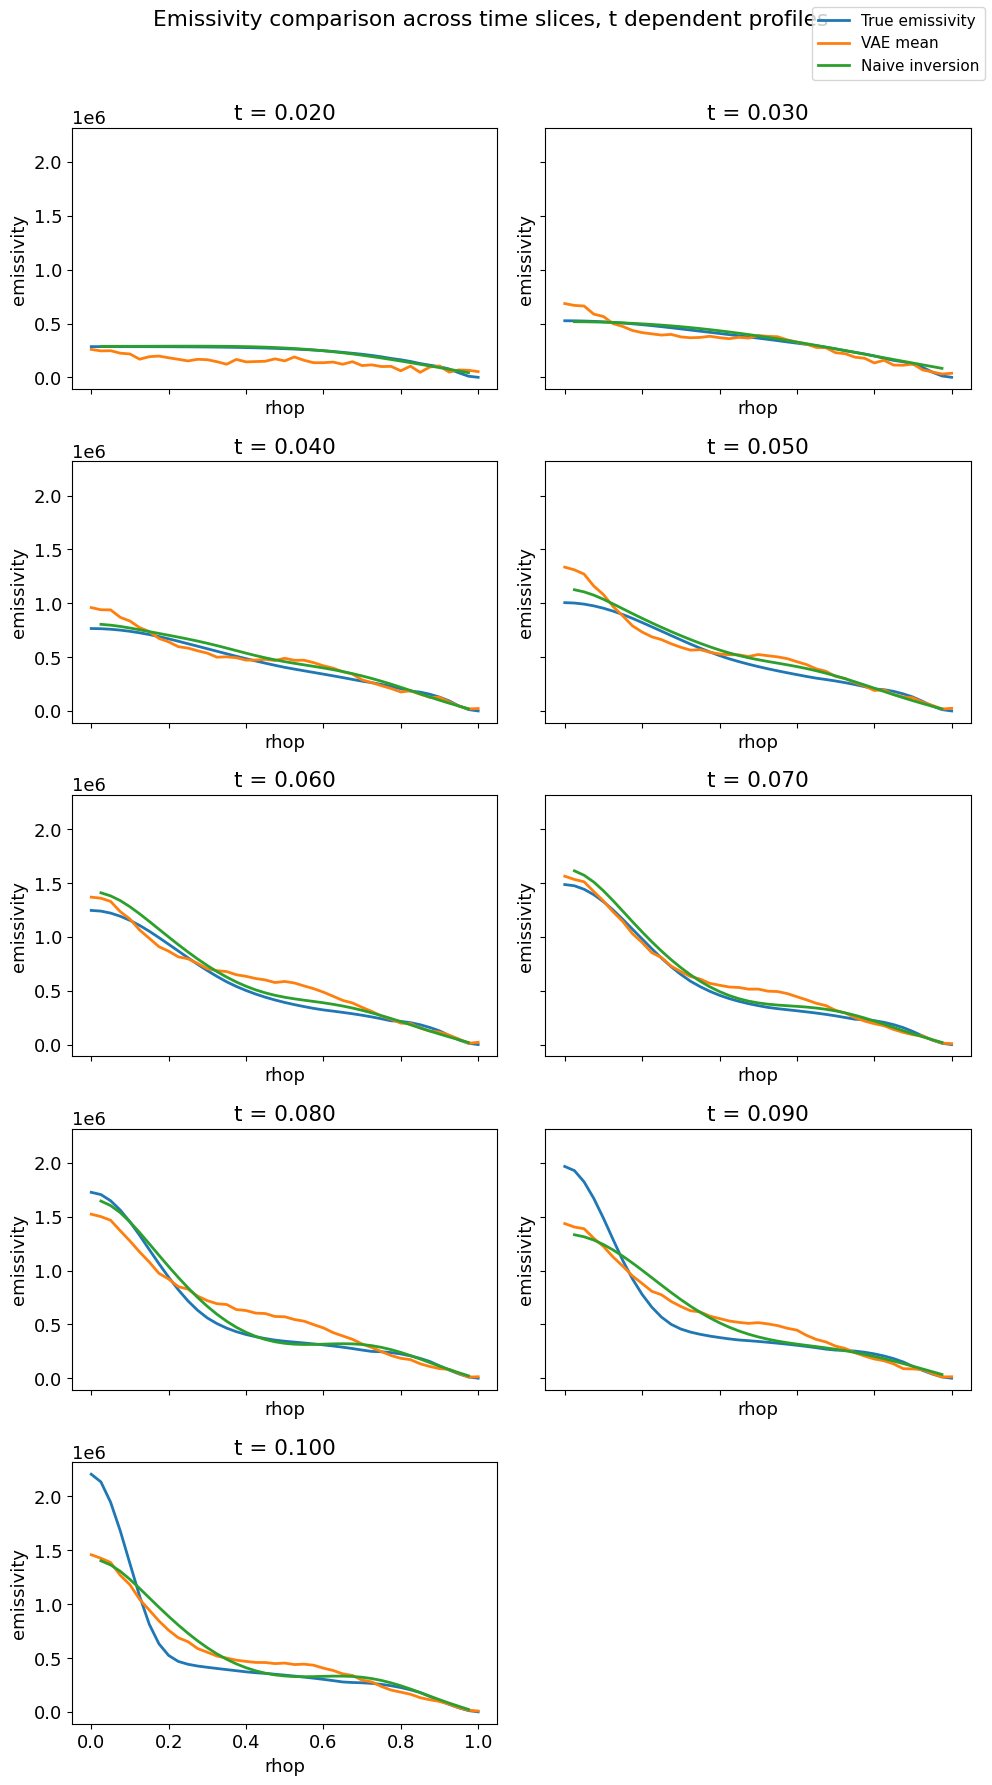

In [ ]:
#Tomography inversion vs vae across time slices for a time dependent plasma
from indica.workflows.los_bolometry_radiation import calculate_tomo_inversion
import xarray as xr

# Dataset stats for normalization
dataset = PairDataset(b_dir, eps_dir)

# Use the model to get a brightness/emissivity time series
generator=PlasmaGenerator(model,transform)
#generator.generate()
plasma = load_default_objects(machine, "plasma")
plasma.set_equilibrium(equilibrium)
brightness, emissivity_tmp=generator.run_model(target_plasma=plasma)
print(emissivity_tmp.shape)
print(brightness.shape)
print(emissivity_tmp)

# Select one timepoint or all timepoints
use_all_timepoints_plot = True
if use_all_timepoints_plot:
    t_indices = np.arange(brightness.sizes["t"], dtype=int)
else:
    t_indices = np.array([np.random.randint(brightness.sizes["t"])] , dtype=int)

# Compute tomography inversion only for selected times
brightness_sel = brightness.isel(t=t_indices)
print("Selected brightness shape for tomography:", brightness_sel.shape)
tomo_inv = calculate_tomo_inversion(brightness_sel, model.transform, emissivity_tmp.rhop)

# Plot comparisons
if len(t_indices) == 1:
    fig, axes = plt.subplots(1, 1, figsize=(6, 4))
    axes = np.array([axes])
else:
    n_cols = 2
    n_rows = int(np.ceil(len(t_indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.5 * n_rows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

for ax in axes[len(t_indices):]:
    ax.axis("off")

for ax, ti, ti_sel in zip(axes[:len(t_indices)], t_indices, range(len(t_indices))):
    # True emissivity at time ti
    e_true = emissivity_tmp.isel(t=ti).values

    # VAE: normalize brightness, sample K, decode, then unnormalize emissivity
    b_t = brightness.isel(t=ti).values.astype(np.float32)
    b_t_norm = (b_t - dataset.mu_b) / dataset.sigma_b
    b_t_norm = torch.from_numpy(b_t_norm).unsqueeze(0)

    K = 20
    latent_dim = vaemodel.fc3m.out_features
    z = torch.randn(K, latent_dim)
    b_rep = b_t_norm.expand(K, -1)
    with torch.no_grad():
        e_samps = vaemodel.decode(b_rep, z)
        e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
        e_vae = e_samps_un.mean(dim=0).cpu().numpy()

    # Tomography inversion at time ti
    e_tomo = tomo_inv.isel(t=ti_sel).values

    ax.plot(emissivity_tmp.rhop, e_true, label="True emissivity")
    ax.plot(emissivity_tmp.rhop, e_vae, label="VAE mean")
    ax.plot(emissivity_tmp.rhop, e_tomo, label="Naive inversion")
    ax.set_title(f"t = {float(brightness.t.values[ti]):.3f}")
    ax.set_xlabel("rhop")
    ax.set_ylabel("emissivity")

# One legend for all
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Emissivity comparison across time slices, t dependent profiles", y=1.02)
fig.tight_layout()


Used 900/100 plasmas (after NaN filtering)
VAE RMSE:  mean=82242.8594  std=92472.0391
Tomo RMSE: mean=26110.2305  std=27714.0527


Text(0.02, 0.98, 'VAE wins: 0.1%\nmedian Δ=-38732.0625')

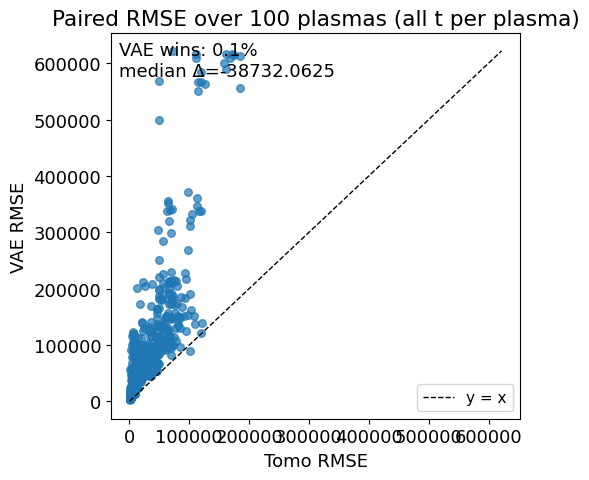

In [ ]:
# Compare VAE vs 1D tomography over multiple generated plasmas
import numpy as np
import torch

n_plasmas = 100
K = 50

dataset = PairDataset(b_dir, eps_dir)
latent_dim = vaemodel.fc3m.out_features

vae_rmse = []
tomo_rmse = []

rng = np.random.default_rng(0)  # reproducible time index selection
use_all_timepoints_eval = True  # Set True when generated plasma has meaningful time dynamics.

for i in range(n_plasmas):
    generator.generate()
    measurements, emissivity = generator.run_model()

    if use_all_timepoints_eval:
        t_indices = np.arange(measurements.sizes["t"], dtype=int)
    else:
        t_indices = np.array([int(rng.integers(0, measurements.sizes["t"]))], dtype=int)

    # Tomography inversion only for selected times
    tomo_inv = calculate_tomo_inversion(measurements.isel(t=t_indices), model.transform, emissivity.rhop)

    for ti_sel, t0 in enumerate(t_indices):
        # Ground truth emissivity
        e_true = emissivity.isel(t=t0).values.astype(np.float32)

        # Tomography inversion
        e_tomo = tomo_inv.isel(t=ti_sel).values.astype(np.float32)

        # VAE inversion
        b_t = measurements.isel(t=t0).values.astype(np.float32)
        b_t_norm = (b_t - dataset.mu_b) / dataset.sigma_b
        b_t_norm = torch.from_numpy(b_t_norm).unsqueeze(0)

        z = torch.randn(K, latent_dim)
        b_rep = b_t_norm.expand(K, -1)
        with torch.no_grad():
            e_samps = vaemodel.decode(b_rep, z)
            e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
            e_vae = e_samps_un.mean(dim=0).cpu().numpy()

        # Filter NaNs from tomography (and align true/vae)
        valid = np.isfinite(e_tomo) & np.isfinite(e_true) & np.isfinite(e_vae)
        if not np.any(valid):
            continue

        e_true_v = e_true[valid]
        e_tomo_v = e_tomo[valid]
        e_vae_v = e_vae[valid]

        # RMSE across rhop (valid points only)
        vae_rmse.append(np.sqrt(np.mean((e_vae_v - e_true_v) ** 2)))
        tomo_rmse.append(np.sqrt(np.mean((e_tomo_v - e_true_v) ** 2)))

vae_rmse = np.array(vae_rmse)
tomo_rmse = np.array(tomo_rmse)

print(f'Used {len(vae_rmse)}/{n_plasmas} plasmas (after NaN filtering)')
print(f'VAE RMSE:  mean={vae_rmse.mean():.4f}  std={vae_rmse.std():.4f}')
print(f'Tomo RMSE: mean={tomo_rmse.mean():.4f}  std={tomo_rmse.std():.4f}')

# Paired scatter with y=x line
plt.figure(figsize=(5.5, 5))
plt.scatter(tomo_rmse, vae_rmse, alpha=0.7, s=30)
mn = min(tomo_rmse.min(), vae_rmse.min())
mx = max(tomo_rmse.max(), vae_rmse.max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='y = x')
plt.xlabel('Tomo RMSE')
plt.ylabel('VAE RMSE')
eval_mode_txt = 'all t per plasma' if use_all_timepoints_eval else 'one random t per plasma'
plt.title(f'Paired RMSE over {n_plasmas} plasmas ({eval_mode_txt})')
plt.legend()
plt.tight_layout()

# Win rate + median delta text (still helpful context)
delta = tomo_rmse - vae_rmse
win_rate = 100.0 * np.mean(delta > 0)
plt.gca().text(0.02, 0.98,
             f'VAE wins: {win_rate:.1f}%\nmedian Δ={np.median(delta):.4f}',
             transform=plt.gca().transAxes, va='top')


/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'ion_temperature_phantom_run_all_params': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


no profile params given so updating all


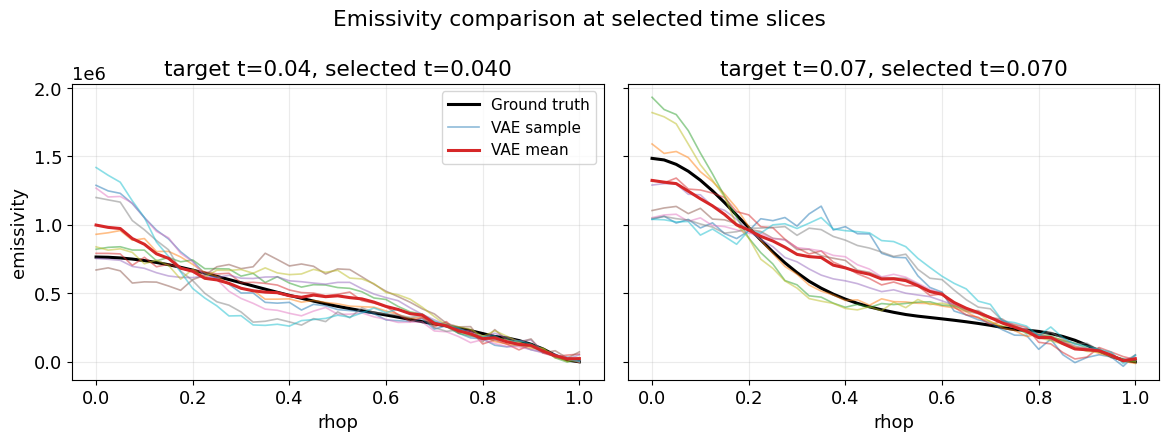

In [ ]:
# Subplots at fixed time slices: t=0.04 and t=0.07
import numpy as np
import torch
import matplotlib.pyplot as plt

dataset = PairDataset(b_dir, eps_dir)

generator=PlasmaGenerator(model,transform)
#generator.generate()
plasma = load_default_objects(machine, "plasma")
plasma.set_equilibrium(equilibrium)
brightness, emissivity_tmp=generator.run_model(target_plasma=plasma)

target_times = [0.04, 0.07]
n_samples = 10
latent_dim = vaemodel.fc3m.out_features
t_values = np.asarray(brightness.t.values, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

for ax, t_target in zip(axes, target_times):
    t_idx = int(np.argmin(np.abs(t_values - t_target)))
    t_sel = float(t_values[t_idx])

    e_true = emissivity_tmp.isel(t=t_idx).values.astype(np.float32)
    b_t = brightness.isel(t=t_idx).values.astype(np.float32)
    b_t_norm = torch.from_numpy((b_t - dataset.mu_b) / dataset.sigma_b).unsqueeze(0)

    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        b_rep = b_t_norm.expand(n_samples, -1)
        e_samps = vaemodel.decode(b_rep, z)
        e_samps_un = (e_samps * dataset.sigma_eps + dataset.mu_eps).cpu().numpy()

    e_vae_mean = e_samps_un.mean(axis=0)

    ax.plot(emissivity_tmp.rhop, e_true, color="k", linewidth=2.2, label="Ground truth")
    for i in range(n_samples):
        label = "VAE sample" if i == 0 else None
        ax.plot(emissivity_tmp.rhop, e_samps_un[i], alpha=0.5, linewidth=1.2, label=label)
    ax.plot(emissivity_tmp.rhop, e_vae_mean, color="tab:red", linewidth=2.2, label="VAE mean")
    ax.set_title(f"target t={t_target:.2f}, selected t={t_sel:.3f}")
    ax.set_xlabel("rhop")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("emissivity")
axes[0].legend()
fig.suptitle("Emissivity comparison at selected time slices")
fig.tight_layout()


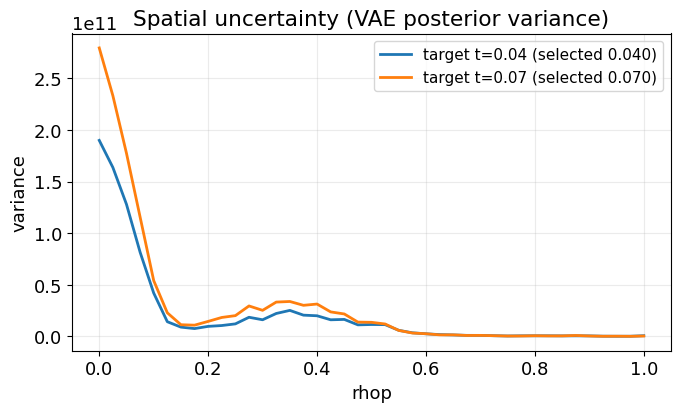

In [ ]:
# Spatial uncertainty map: posterior variance vs rhop at t=0.04 and t=0.07
import numpy as np
import torch
import matplotlib.pyplot as plt

target_times = [0.04, 0.07]
n_samples = 200
latent_dim = vaemodel.fc3m.out_features
t_values = np.asarray(brightness.t.values, dtype=float)
rhop = np.asarray(emissivity_tmp.rhop.values, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4.5))

for t_target in target_times:
    t_idx = int(np.argmin(np.abs(t_values - t_target)))
    t_sel = float(t_values[t_idx])
    

    b_t = brightness.isel(t=t_idx).values.astype(np.float32)
    b_t_norm = torch.from_numpy((b_t - dataset.mu_b) / dataset.sigma_b).unsqueeze(0)

    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        b_rep = b_t_norm.expand(n_samples, -1)
        e_samps = vaemodel.decode(b_rep, z)
        e_samps_un = (e_samps * dataset.sigma_eps + dataset.mu_eps).cpu().numpy()

    e_var = e_samps_un.var(axis=0)
    ax.plot(rhop, e_var, linewidth=2, label=f"target t={t_target:.2f} (selected {t_sel:.3f})")

ax.set_xlabel("rhop")
ax.set_ylabel("variance")
ax.set_title("Spatial uncertainty (VAE posterior variance)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
